In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car_sales_new.csv')
df.head(25)

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,NaN
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9065 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


In [4]:
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending =False)
percent

,0
drive,0.053363
engV,0.045322
price,0.000000
car,0.000000
mileage,0.000000
body,0.000000
engType,0.000000
registration,0.000000
year,0.000000
model,0.000000


In [5]:
df.describe()

,price,mileage,engV,year
count,9576.000000,9576.000000,9142.000000,9576.000000
mean,15633.317316,138.862364,2.646344,2006.605994
std,24106.523436,98.629754,5.927699,7.067924
min,0.000000,0.000000,0.100000,1953.000000
25%,4999.000000,70.000000,1.600000,2004.000000
50%,9200.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.500000,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [6]:
print("How many values are 0 ? " , df.price[df.price == 0 ].count())

How many values are 0 ?  267


In [7]:
print("How many values are 0 ? " , df.mileage[df.mileage == 0 ].count())

How many values are 0 ?  348


In [8]:
df.columns = map(str.lower , df.columns)
df.dtypes

,0
car,object
price,float64
body,object
mileage,int64
engv,float64
engtype,object
registration,object
year,int64
model,object
drive,object


In [9]:
df.head(25)

,car,price,body,mileage,engv,engtype,registration,year,model,drive
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,NaN
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear


In [10]:
df['drive'] =df['drive'].fillna("Unspecified")

In [11]:
df['engv'].fillna(df['engv'].mean() , inplace = True)

/tmp/ipython-input-471868306.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engv'].fillna(df['engv'].mean() , inplace = True)


In [12]:
df['price'] = df['price'].replace(0 ,  df['price'].mean())

In [30]:
mileage_avg = sum(df['mileage']) / len(df['mileage'])
df['mileage_level'] = ["high mileage" if i > mileage_avg else "low mileage" for i in df['mileage']]
df.loc[:10]

,car,price,body,mileage,engv,engtype,registration,year,model,drive,mileage_avg,mileage_level
0,Ford,15500.000,crossover,68,2.500000,Gas,yes,2010,Kuga,full,low mileage,low mileage
1,Mercedes-Benz,20500.000,sedan,173,1.800000,Gas,yes,2011,E-Class,rear,high mileage,high mileage
2,Mercedes-Benz,35000.000,other,135,5.500000,Petrol,yes,2008,CL 550,rear,low mileage,low mileage
3,Mercedes-Benz,17800.000,van,162,1.800000,Diesel,yes,2012,B 180,front,high mileage,high mileage
4,Mercedes-Benz,33000.000,vagon,91,2.646344,Other,yes,2013,E-Class,Unspecified,low mileage,low mileage
5,Nissan,16600.000,crossover,83,2.000000,Petrol,yes,2013,X-Trail,full,low mileage,low mileage
6,Honda,6500.000,sedan,199,2.000000,Petrol,yes,2003,Accord,front,high mileage,high mileage
7,Renault,10500.000,vagon,185,1.500000,Diesel,yes,2011,Megane,front,high mileage,high mileage
8,Mercedes-Benz,21500.000,sedan,146,1.800000,Gas,yes,2012,E-Class,rear,high mileage,high mileage
9,Mercedes-Benz,22700.000,sedan,125,2.200000,Diesel,yes,2010,E-Class,rear,low mileage,low mileage


<Axes: xlabel='year'>

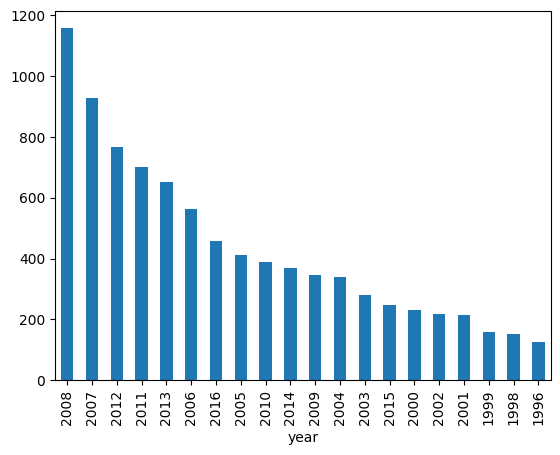

In [14]:
df['year'].value_counts().head(20).plot.bar()

<Axes: xlabel='car'>

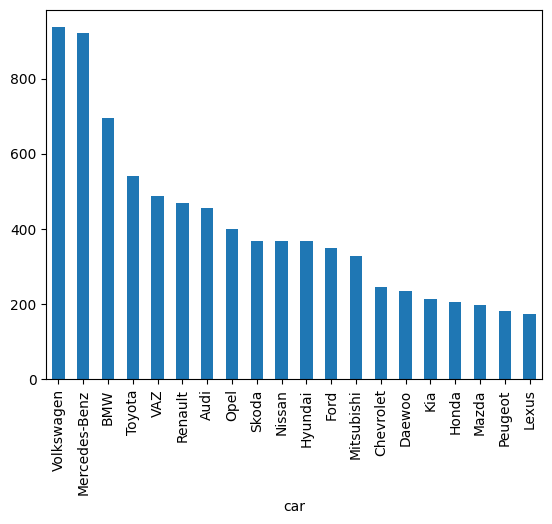

In [15]:
df['car'].value_counts().head(20).plot.bar()

/tmp/ipython-input-1368679925.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_10_model['model'], y = top_10_model.index, palette="PuBuGn_d")


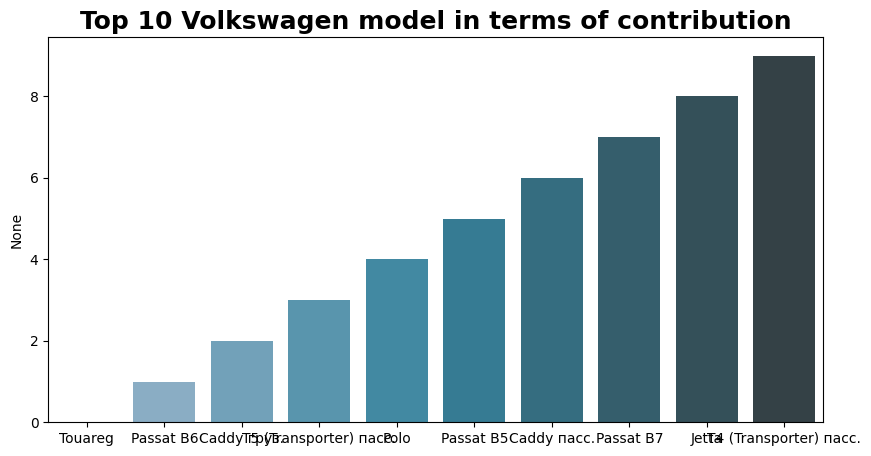

In [20]:
usa = df.loc[df['car'] == 'Volkswagen']

top_10_model = (
    usa['model']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_model.columns = ['model', 'count']

plt.figure(figsize=(10,5))

sns.barplot(x = top_10_model['model'], y = top_10_model.index, palette="PuBuGn_d")
plt.title('Top 10 Volkswagen model in terms of contribution', fontsize=18, fontweight="bold")
plt.xlabel("")
plt.show()


/tmp/ipython-input-1731311052.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ct = pd.value_counts(df['engtype'].values, sort = False)


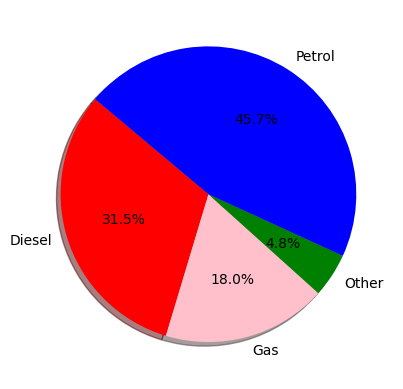

In [21]:
ct = pd.value_counts(df['engtype'].values, sort = False)
labels = df['engtype'].unique()
labels.sort()
sizes = ct
ct.sort_index(inplace = True)
colors = ['red', 'pink', 'green', 'blue']
plt.pie(sizes, labels = labels, colors = colors,
autopct='%1.1f%%', shadow = True, startangle = 140)
plt.show()


<Axes: xlabel='mileage', ylabel='price'>

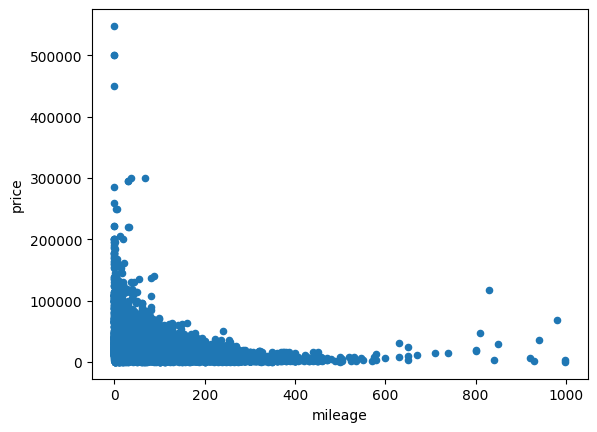

In [22]:
df.plot.scatter(x = 'mileage' , y ='price')

<Axes: xlabel='mileage', ylabel='price'>

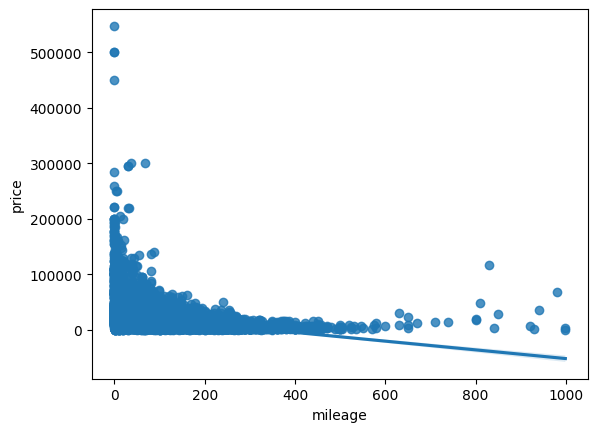

In [23]:
sns.regplot(x = 'mileage' , y ='price' , data =df )

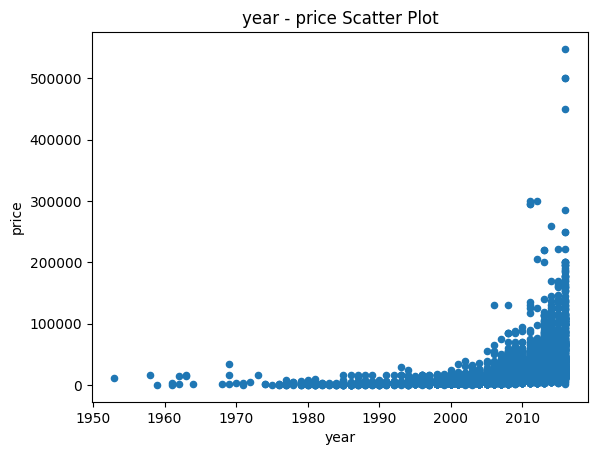

In [24]:
df.plot(kind = 'scatter', x='year', y = 'price')
plt.xlabel("year")
plt.ylabel("price")
plt.title("year - price Scatter Plot")
plt.show()

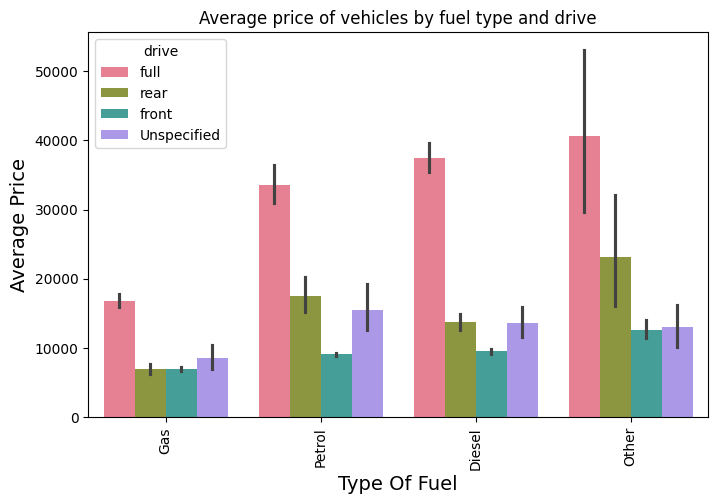

In [25]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(x="engtype", y="price", hue= "drive", palette="husl", data = df)
ax.set_title("Average price of vehicles by fuel type and drive", fontdict= {'size':12})
ax.xaxis.set_label_text("Type Of Fuel", fontdict= {'size':14})
ax.yaxis.set_label_text("Average Price", fontdict= {'size':14})
ticks = plt.setp(ax.get_xticklabels(),rotation = 90)
plt.show()


In [27]:
print(Carsales_Sample.columns)

Index(['car', 'price', 'body', 'mileage', 'engv', 'engtype', 'registration',
       'year', 'model', 'drive', 'mileage_avg'],
      dtype='object')


In [29]:
df['mileage_level'] = pd.cut(
    df['mileage_avg'],
    bins=[0, 50000, 100000, 150000, df['mileage_avg'].max()],
    labels=['Low', 'Medium', 'High', 'Very High']
)

ValueError: bins must increase monotonically.

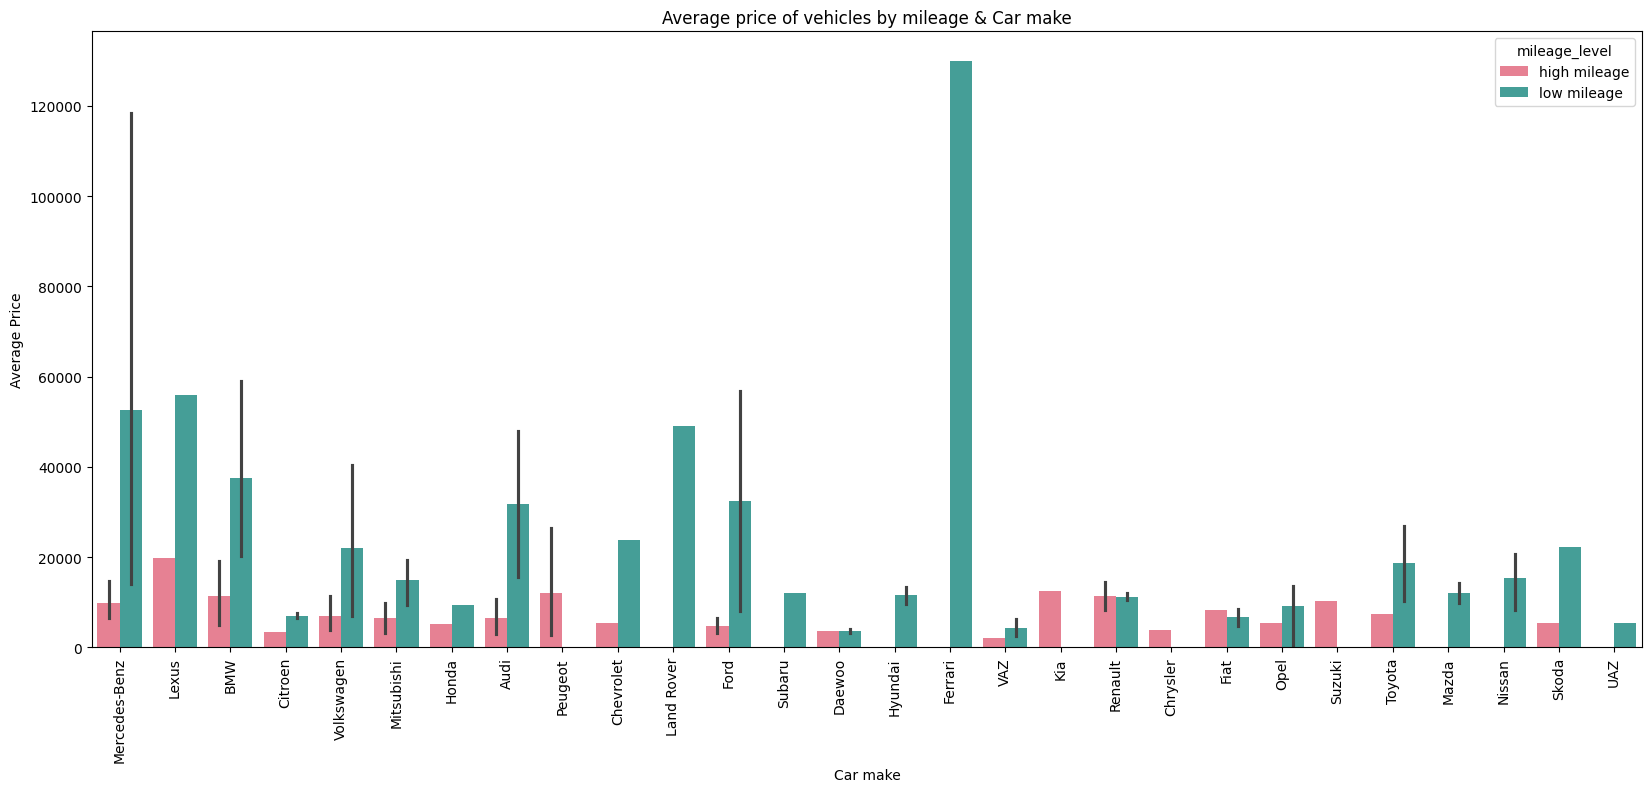

In [31]:
fig, ax = plt.subplots(figsize=(20, 8))

Carsales_Sample = df.sample(100)

sns.barplot(
    x="car",
    y="price",
    hue="mileage_level",
    palette="husl",
    data=Carsales_Sample
)

ax.set_title("Average price of vehicles by mileage & Car make", fontdict= {'size':12})
ax.xaxis.set_label_text("Car make", fontdict= {'size':10})
ax.yaxis.set_label_text("Average Price", fontdict= {'size':10})
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
plt.show()


In [32]:
corr = df.loc[: , df.dtypes != 'object'].corr(method = 'pearson')
corr

,price,mileage,engv,year
price,1.000000,-0.323532,0.051910,0.380048
mileage,-0.323532,1.000000,0.045642,-0.495599
engv,0.051910,0.045642,1.000000,-0.040742
year,0.380048,-0.495599,-0.040742,1.000000


<Axes: >

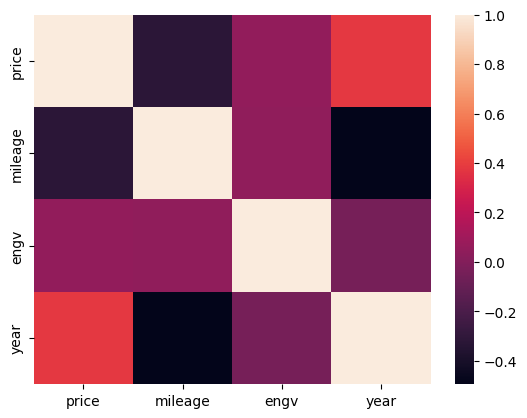

In [33]:
sns.heatmap(corr , xticklabels = corr.columns , yticklabels = corr.columns)